In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from statannotations.Annotator import Annotator

In [2]:
#Reading the data: This is to prep the data for cleaning. Returns a DtypeWarning which is then handled by determining which column it is.
df = pd.read_csv('Downloads/Dual_Credit_Dashboard_Data.csv')

C:\Users\taylo\AppData\Local\Temp\ipykernel_15240\4168331382.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Downloads/Dual_Credit_Dashboard_Data.csv')


In [3]:
#Finds which column has the Dtypewarning error.
print(df.columns[0])
#Where the error is occuring.
df.iloc[:,0].apply(type).value_counts()

Cohort


Cohort
<class 'int'>    1441792
<class 'str'>     245078
Name: count, dtype: int64

In [4]:
#Cleaning the data: 1) Drops the values where Cohort = string
df["Cohort"] = pd.to_numeric(df["Cohort"], errors = "coerce")
#2) Drop values with Nan and keep only data where county is equal to Tacoma School District, Yakima School District or Bellevue School District.
#County is equal to Tacoma School District, Yakima School District or Bellevue School District
df_filter = df.loc[df['K12District'].isin([
    'Tacoma School District',
    'Yakima School District',
    'Bellevue School District'
])]
#Drop all NaN values
df_cleaned = df_filter.dropna(subset= ['Cohort'])
#Drop years that are not equal to 2024
df_cleaned = df_cleaned[df_cleaned['Cohort'] ==2024]
print(df_cleaned)
# This is just to confirm the years returned in the data.
df_cleaned['Cohort'].unique()
#Cleaned up Pct of Students column, where the same Dtypewarning occurs
df_cleaned["Pct of Students Rounded"] = df_cleaned["Pct of Students Rounded"].astype(str)
print(df_cleaned)

         Cohort               K12District        Gender Race/Ethnicity  \
1331064  2024.0  Bellevue School District  All Students   All Students   
1331065  2024.0  Bellevue School District  All Students   All Students   
1331066  2024.0  Bellevue School District  All Students   All Students   
1331067  2024.0  Bellevue School District  All Students   All Students   
1331068  2024.0  Bellevue School District  All Students   All Students   
...         ...                       ...           ...            ...   
1475149  2024.0    Yakima School District             X   All Students   
1475150  2024.0    Yakima School District             X   All Students   
1475151  2024.0    Yakima School District             X   All Students   
1475152  2024.0    Yakima School District             X   All Students   
1475153  2024.0    Yakima School District             X   All Students   

        K12ExitStatus      Group By Group Value                 Measure  \
1331064  All Students  All Students 

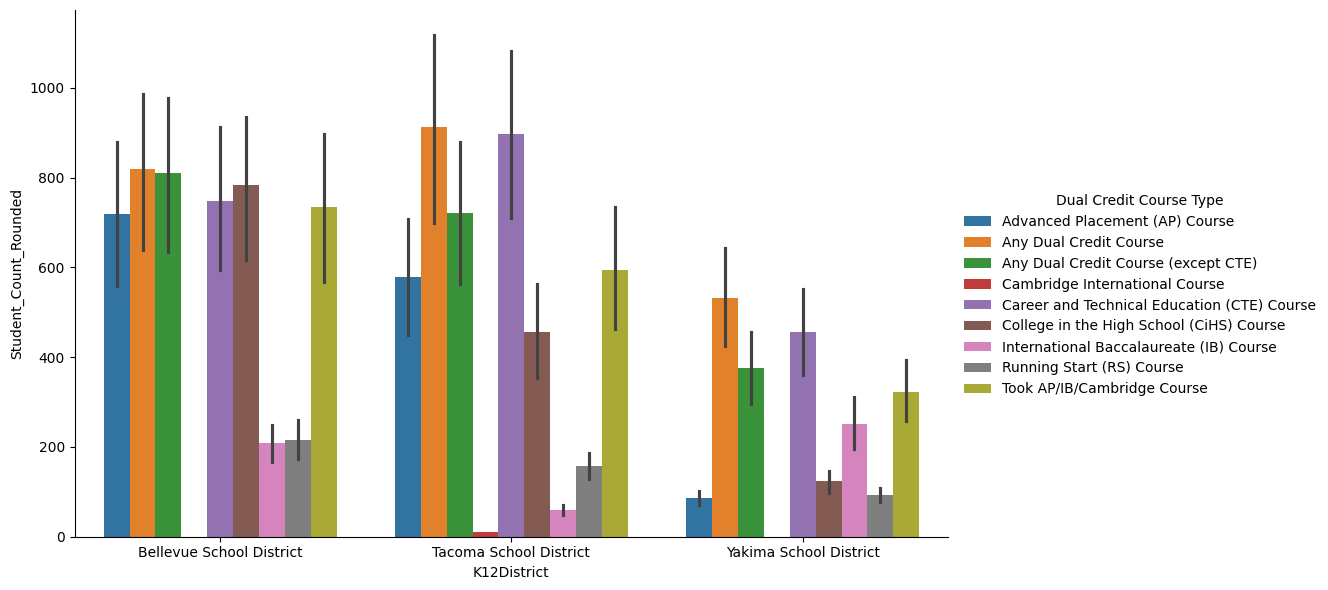

In [5]:
#Model the data
#Group selected school districts by dual credit course type and selected districts.
sns.catplot(
    x="K12District",
    y="Student_Count_Rounded",
    hue="Dual Credit Course Type",
    data=df_cleaned,
    kind="bar",
    height= 6, 
    aspect=1.66
)

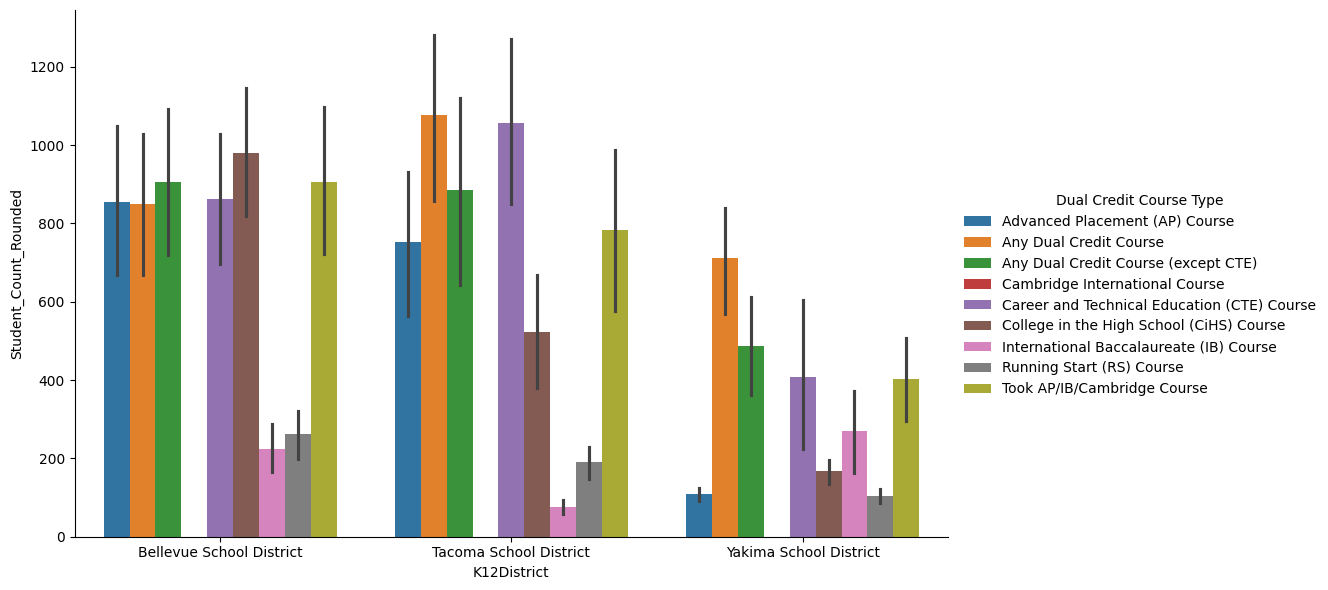

In [6]:
#This graph illustrates which credit courses are the most popular ammong students that have a high success rate (90% and above).
df_high = df_cleaned[df_cleaned['Pct of Students Rounded'] > '90']
sns.catplot(
    x="K12District",
    y="Student_Count_Rounded",
    hue="Dual Credit Course Type",
    data=df_high,
    kind="bar",
    height= 6, 
    aspect=1.66
)

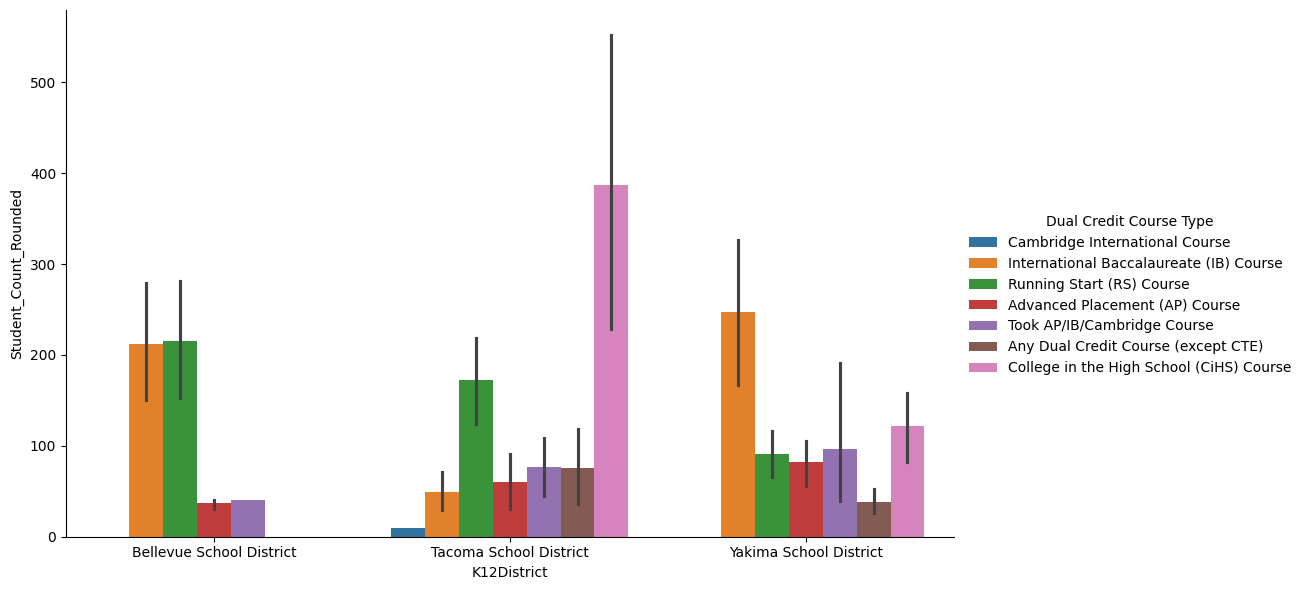

In [7]:
#This graph illustrates which credit courses are the most popular ammong students that have a low success rate (50% and below).
df_high = df_cleaned[df_cleaned['Pct of Students Rounded'] < '50']
sns.catplot(
    x="K12District",
    y="Student_Count_Rounded",
    hue="Dual Credit Course Type",
    data=df_high,
    kind="bar",
    height= 6, 
    aspect=1.66
)

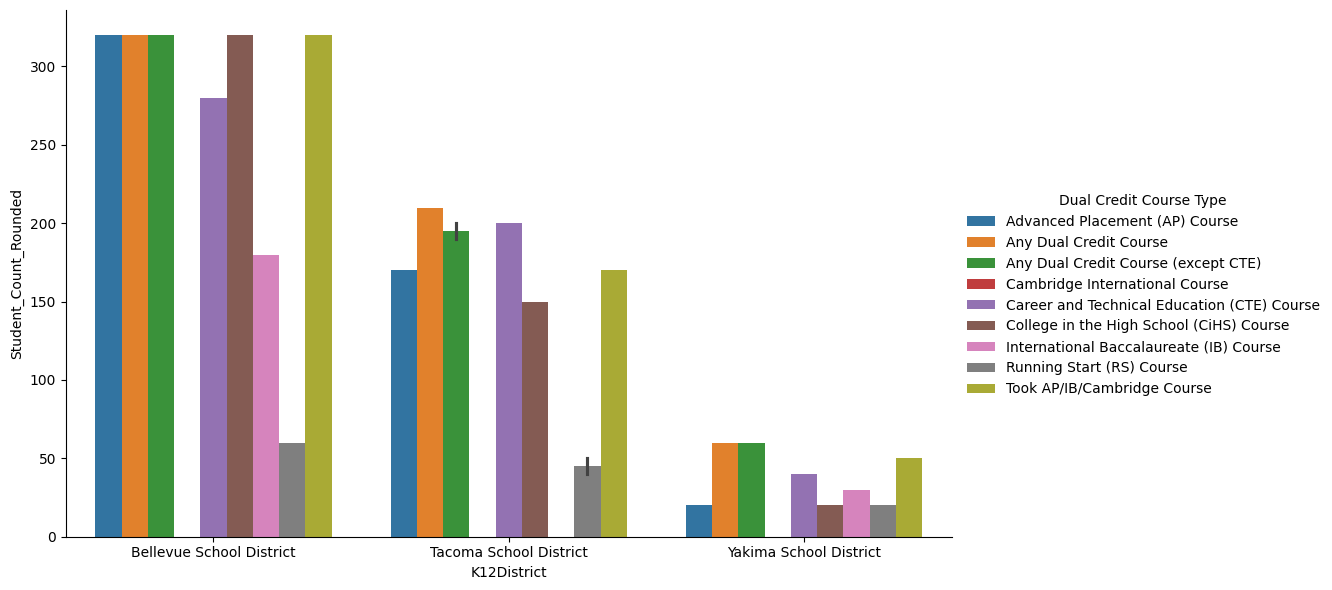

In [8]:
#Are there differences by students' status where some programs are more popular than others? (Highly Capable Program)
df_hc = df_cleaned[df_cleaned['Group Value'] == 'Highly Capable Program']
sns.catplot(
    x="K12District",
    y="Student_Count_Rounded",
    hue="Dual Credit Course Type",
    data=df_hc,
    kind="bar",
    height= 6, 
    aspect=1.66
)

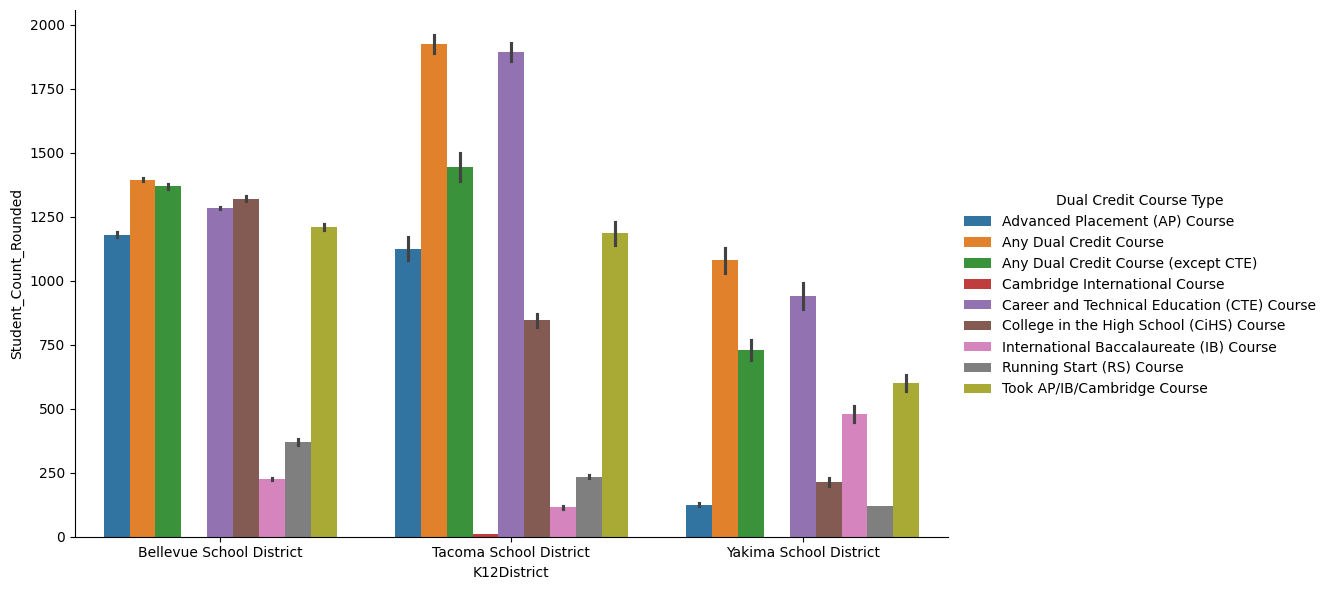

In [9]:
#Are there differences by students' status where some programs are more popular than others? (Not Highly Capable Program)
df_status = df_cleaned[df_cleaned['Group Value'] == 'Not Highly Capable Program']
sns.catplot(
    x="K12District",
    y="Student_Count_Rounded",
    hue="Dual Credit Course Type",
    data=df_status,
    kind="bar",
    height= 6, 
    aspect=1.66
)

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Tacoma School District_Dual Credit Completion vs. Tacoma School District_Dual Credit Enrollment: t-test independent samples, P_val:8.605e-01 t=1.788e-01
Yakima School District_Dual Credit Completion vs. Yakima School District_Dual Credit Enrollment: t-test independent samples, P_val:7.698e-01 t=-2.983e-01


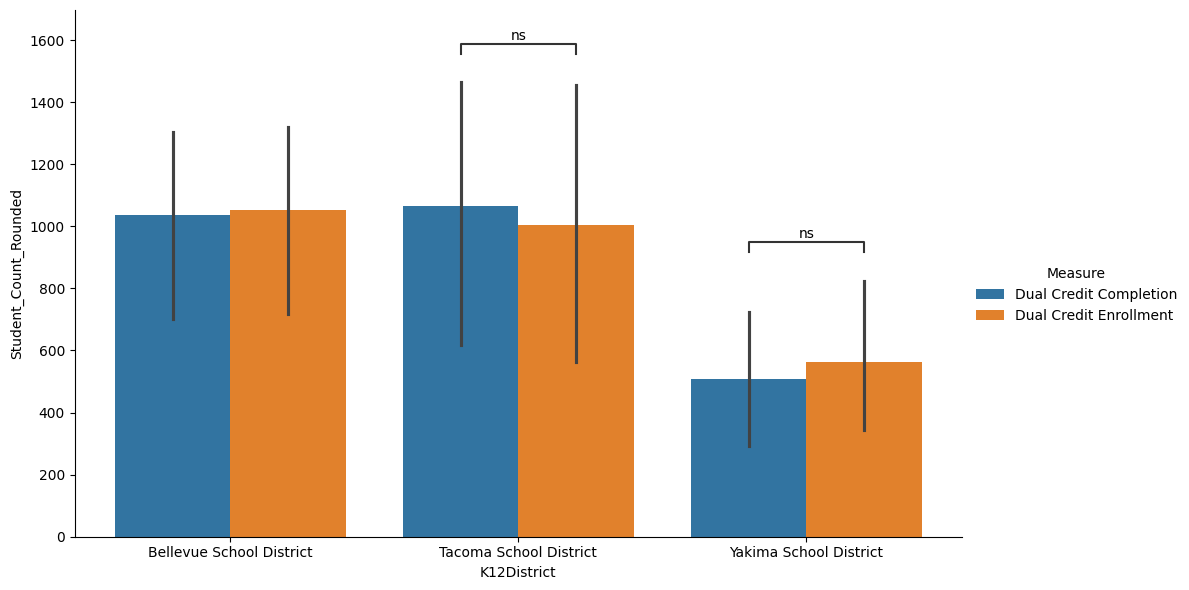

In [10]:
#Are there significant differences between students deemed highly capable versus not?
df_measure = df_cleaned[df_cleaned['Group Value'] == 'Not Highly Capable Program']
df_siggraph= sns.catplot(
    x="K12District",
    y="Student_Count_Rounded",
    hue="Measure",
    data=df_measure,
    kind="bar",
    height= 6, 
    aspect=1.66
)
#Based on the Not Highly Capable results for Yakima, is the difference between Dual Credit Enrollment and Dual Credit Completion statistically significant? 
pairs = [(("Yakima School District", "Dual Credit Enrollment"), ("Yakima School District", "Dual Credit Completion")), (("Tacoma School District", "Dual Credit Enrollment"), ("Tacoma School District", "Dual Credit Completion"))]
ax = df_siggraph.ax 

annotator = Annotator(ax, pairs, data=df_measure, x="K12District", y="Student_Count_Rounded", hue="Measure")
annotator.configure(test='t-test_ind', text_format='star', loc='inside')
annotator.apply_and_annotate()

plt.show()


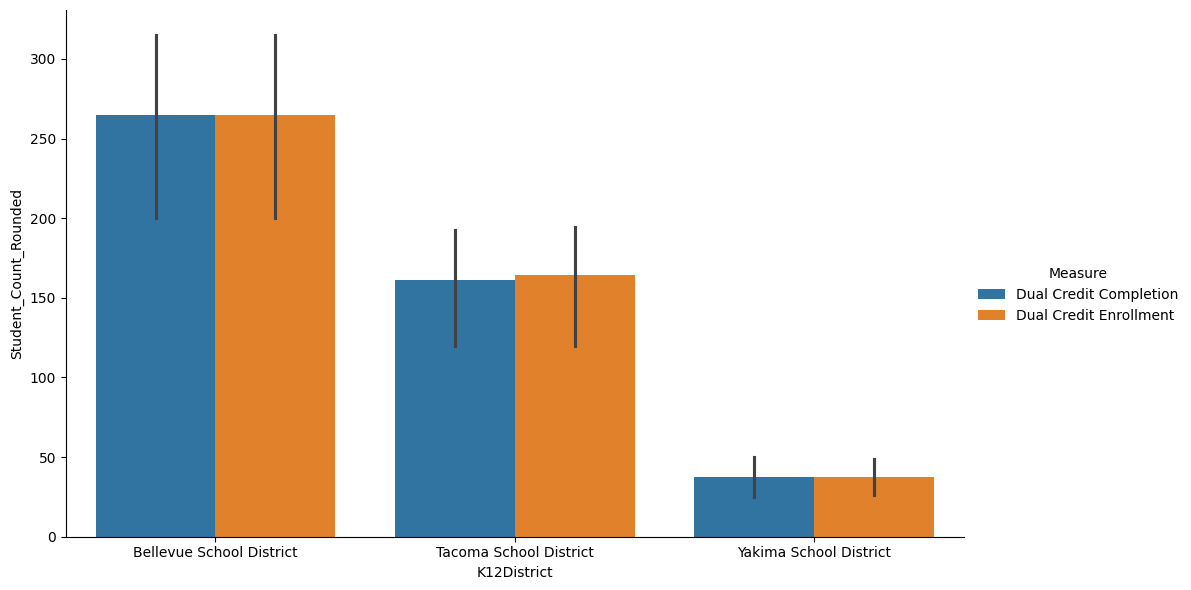

In [11]:
#Are there significant differences between students deemed highly capable versus not?
df_measureii = df_cleaned[df_cleaned['Group Value'] == 'Highly Capable Program']
sns.catplot(
    x="K12District",
    y="Student_Count_Rounded",
    hue="Measure",
    data=df_measureii,
    kind="bar",
    height= 6, 
    aspect=1.66
)


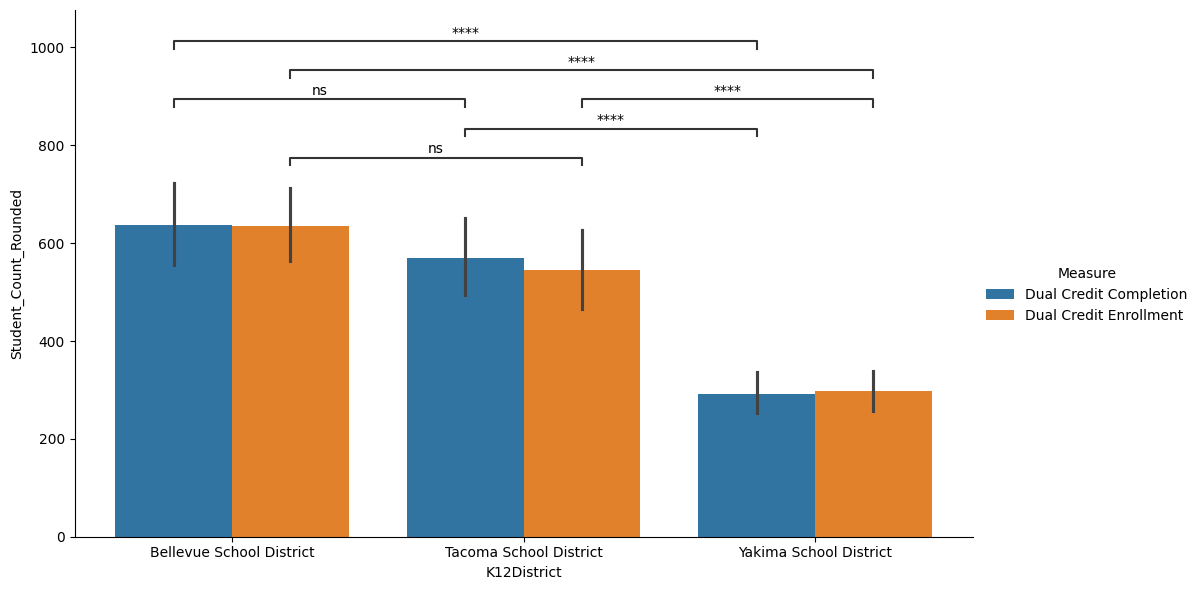

In [13]:
#Are there any significant differences between dual credit enrollment/completion across these 3 districts?
district_order = ['Yakima School District', 'Bellevue School District', 'Tacoma School District']
measure_order = ['Dual Credit Enrollment', 'Dual Credit Completion']

sig_between = {
    "x": "K12District",
    "y": "Student_Count_Rounded",
    "hue": "Measure",
    "data": df_cleaned,
    "kind": "bar",
    "height": 6, 
    "aspect": 1.66
}
sig_between_gr = sns.catplot(**sig_between)

sig_between_pairs = [
    (("Yakima School District", "Dual Credit Enrollment"), ("Tacoma School District", "Dual Credit Enrollment")),
    (("Yakima School District", "Dual Credit Enrollment"), ("Bellevue School District", "Dual Credit Enrollment")),
    (("Bellevue School District", "Dual Credit Enrollment"), ("Tacoma School District", "Dual Credit Enrollment")),
    (("Yakima School District", "Dual Credit Completion"), ("Tacoma School District", "Dual Credit Completion")),
    (("Yakima School District", "Dual Credit Completion"), ("Bellevue School District", "Dual Credit Completion")),
    (("Bellevue School District", "Dual Credit Completion"), ("Tacoma School District", "Dual Credit Completion"))]
    
sigbtwnpairs = Annotator(sig_between_gr.ax,sig_between_pairs, **sig_between)
sigbtwnpairs.configure(
    test='t-test_ind',
    text_format='star',         
    loc='inside',               
    verbose=False               
)

sigbtwnpairs.apply_and_annotate()
plt.show()


In [ ]:
#Do any significant differences exist for the 'homeless' and 'low income' categories?
df_measureiii = df_cleaned[df_cleaned['Group Value'] == 'Homeless']
sns.catplot(
    x="K12District",
    y="Student_Count_Rounded",
    hue="Measure",
    data=df_measureiii,
    kind="bar",
    height= 6, 
    aspect=1.66
)

df_measureiv = df_cleaned[df_cleaned['Group Value'] == 'Low Income']
df_low_income = sns.catplot(
    x="K12District",
    y="Student_Count_Rounded",
    hue="Measure",
    data=df_measureiv,
    kind="bar",
    height= 6, 
    aspect=1.66
)
pairsi = [(("Yakima School District", "Dual Credit Enrollment"), ("Yakima School District", "Dual Credit Completion")), (("Tacoma School District", "Dual Credit Enrollment"), ("Tacoma School District", "Dual Credit Completion"))]
ax = df_low_income.ax 

annotator = Annotator(ax, pairsi, data=df_measureiv, x="K12District", y="Student_Count_Rounded", hue="Measure")
annotator.configure(test='t-test_ind', text_format='star', loc='inside')
annotator.apply_and_annotate()

plt.show()

df_measurev = df_cleaned[df_cleaned['Group Value'] == 'Not Low Income']
df_notlow_income = sns.catplot(
    x="K12District",
    y="Student_Count_Rounded",
    hue="Measure",
    data=df_measurev,
    kind="bar",
    height= 6, 
    aspect=1.66
)
pairsii = [(("Yakima School District", "Dual Credit Enrollment"), ("Yakima School District", "Dual Credit Completion")), (("Tacoma School District", "Dual Credit Enrollment"), ("Tacoma School District", "Dual Credit Completion"))]
ax = df_notlow_income.ax 

annotator = Annotator(ax, pairsii, data=df_measurev, x="K12District", y="Student_Count_Rounded", hue="Measure")
annotator.configure(test='t-test_ind', text_format='star', loc='inside')
annotator.apply_and_annotate()

plt.show()